# Panorama Stitching Project
### Lorenzo Brizzi

1) LAB- "Matching": apply the results of your matching procedure to image registration or the construction of a mosaic / panoramic image
you are required to use the correspondences to estimate a global transformation (see https://docs.opencv.org/4.x/d9/dab/tutorial_homography.html) you will use to register one image with respect to another

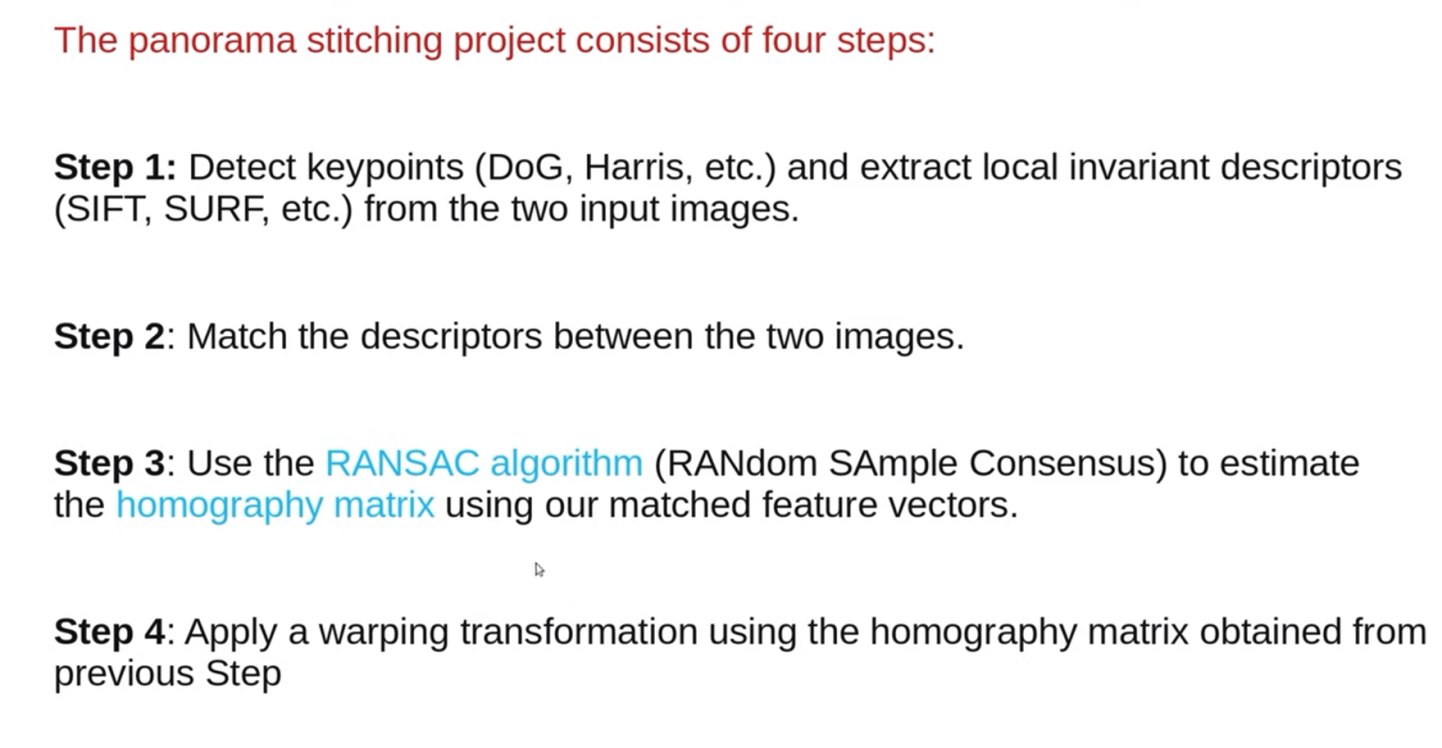

In [1]:
from IPython.display import Image, display
display(Image(filename='images/Untitled picture.png'))

# Final Lab - Matching

---

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import signal, spatial
import matplotlib.pyplot as plt
from matplotlib import cm
from skimage import data, color, img_as_float, img_as_ubyte, filters, feature, util, io
from sklearn import metrics

%matplotlib inline
from IPython.display import HTML, display

In [3]:
def patch_descriptor(I, corner_pos, size_w):
    """Extract square patches around each corner on an input grayscale image. 
    - I: input RGB image
    - corner_pos: list with position of n corners (row,col)
    - size_w: (integer) patch side
   """
    
    n = len(corner_pos) # Number of features
    hw = int(np.floor(size_w/2)) # half size of the patch (useful to center the pat)
    I_ext = np.pad(I, hw, 'reflect') # pad the image with a frame of width hw 
    
    # initialize patches list
    patches = np.zeros([n,(2*hw+1)**2])
    
    for i in range(0, n):
        
        r = corner_pos[i,0]+hw # adjust the row of each corner considering the padding
        c = corner_pos[i,1]+hw # do the same for the column 
        tmp = I_ext[r-hw:r+hw+1, c-hw:c+hw+1] # estract the patch
        patches[i,:] = tmp.flatten() #flatten the patch and save it in the patches list
        
    return patches

def spectral_matching(sigma, patches1, patches2, corner_pos1, corner_pos2, threshold):
    """
    Spectral matching with maxima in both directions and optional thresholding.
    
    - sigma: controls the similarity measure
    - patches1, patches2: feature descriptors for both images
    - corner_pos1, corner_pos2: feature positions
    - threshold: minimum affinity to consider a match
    """
    # Compute pairwise Euclidean distances between patches
    D = spatial.distance.cdist(patches1, patches2, metric='euclidean')
    
    # Compute affinity matrix
    E = np.exp(-D / (2 * sigma**2))
    
    # Apply threshold to retain only strong affinities
    E[E < threshold] = 0  # Discard weak matches based on threshold
    
    # Find maxima in both directions
    argmaxE_h = np.argmax(E, axis=1)
    argmaxE_v = np.argmax(E, axis=0)
    matches = []

    for i, amx in enumerate(argmaxE_h):
        if argmaxE_v[amx] == i:  # Ensure mutual best match
            matches.append((corner_pos1[i], corner_pos2[amx]))
    
    return E, matches

from skimage.measure import ransac
from skimage.transform import AffineTransform

def refine_matches_with_ransac(matches, corners1, corners2):
    """
    Refine matches using RANSAC to enforce geometric consistency.

    - matches: list of matched corner pairs (from `spectral_matching`)
    - corners1, corners2: original corner positions for both images

    Returns:
    - refined_matches: list of inlier matches
    """
    if len(matches) < 4:  # RANSAC needs at least 4 matches
        return matches

    src = np.array([m[0] for m in matches])
    dst = np.array([m[1] for m in matches])

    # Estimate transformation using RANSAC
    model, inliers = ransac((src, dst), AffineTransform, min_samples=4, residual_threshold=2, max_trials=100)

    # Filter matches based on inliers
    refined_matches = [matches[i] for i in range(len(matches)) if inliers[i]]

    return refined_matches


def filter_corners(corners, img_shape, border_size=10):
    """
    Filters out corners near the image border.
    
    - corners: array of corner positions (row, col)
    - img_shape: shape of the image (rows, cols)
    - border_size: minimum distance from border
    """
    valid_corners = [
        corner for corner in corners 
        if border_size <= corner[0] < img_shape[0] - border_size and 
           border_size <= corner[1] < img_shape[1] - border_size
    ]
    return np.array(valid_corners)


def show_match(match, corner_pos1, corner_pos2, img1, img2):
    img = np.concatenate([img1, img2], axis=1)
    plt.imshow(img, cmap=cm.gist_gray)
    
    for match_pair in match:
        plt.plot([match_pair[0][1], match_pair[1][1] + img1.shape[1]],
                 [match_pair[0][0], match_pair[1][0]], 'y')
    
    plt.scatter(corner_pos1[:, 1], corner_pos1[:, 0], s=10, c='r')
    plt.scatter(corner_pos2[:, 1] + img1.shape[1], corner_pos2[:, 0], s=20, c='b')
    return img


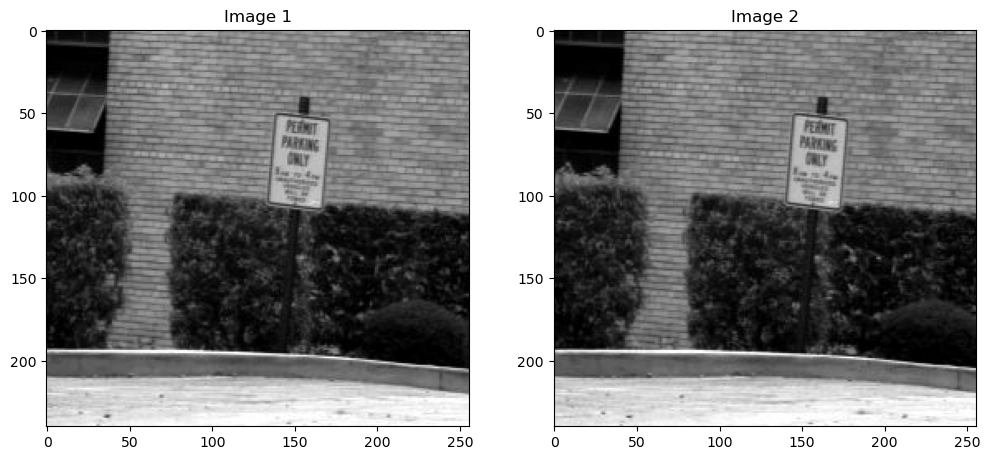

In [4]:
# LOAD IMAGES
RGBimg1 = cv2.imread('images/shrub_L.jpg')  # Source image
RGBimg2 = cv2.imread('images/shrub_R.jpg')  # Destination image
img1 = img_as_float(color.rgb2gray(RGBimg1))
img2 = img_as_float(color.rgb2gray(RGBimg2))
 
#PLOT THEM
plt.figure(figsize=(12,6))
plt.subplot(121)
plt.imshow(RGBimg1, cmap=cm.gist_gray)
plt.title('Image 1')
plt.subplot(122)
plt.imshow(RGBimg2, cmap=cm.gist_gray)
plt.title('Image 2');

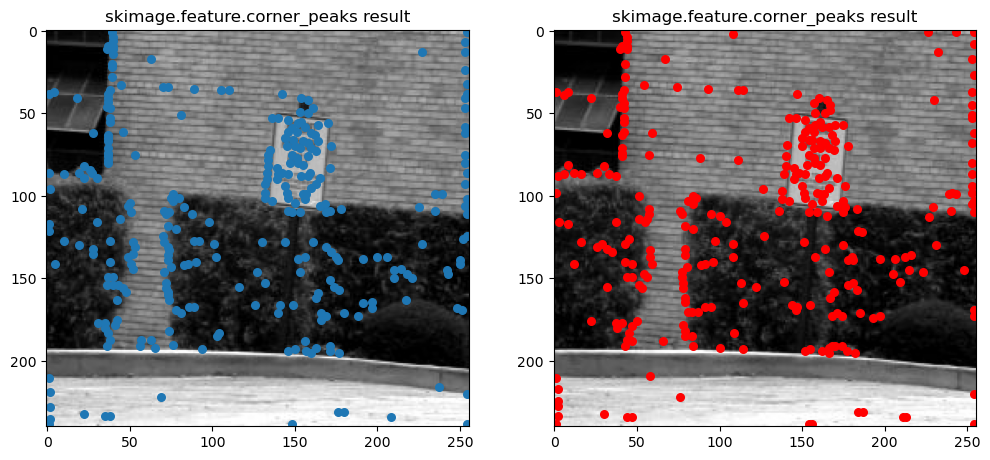

In [5]:
# FEATURE DETECTION
# using the shi-tomasi algorithm, identify the corners in both images
corners1 = feature.corner_peaks(feature.corner_shi_tomasi(img1),num_peaks=300) # IT MAY BE WORTH ADDING num_peaks=300 to corner_peaks
corners2 = feature.corner_peaks(feature.corner_shi_tomasi(img2),num_peaks=300) # IT MAY BE WORTH ADDING num_peaks=300 to corner_peaks

# plot the results on both images side by side
plt.figure(figsize=(12,6))
plt.subplot(121)
plt.imshow(RGBimg1, cmap=cm.gist_gray)
plt.scatter(corners1[:,1], corners1[:,0], s=30)
plt.title('skimage.feature.corner_peaks result')

plt.subplot(122)
plt.imshow(RGBimg2, cmap=cm.gist_gray)
plt.scatter(corners2[:,1], corners2[:,0], s=30, c='r')
plt.title('skimage.feature.corner_peaks result');

Text(0.5, 1.0, 'Refined Matches')

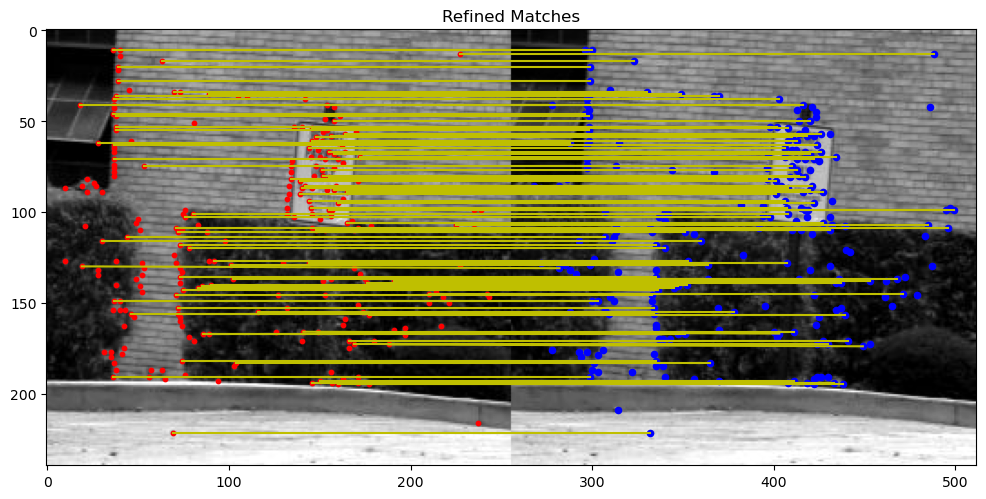

In [6]:
# Filter out corners near the image borders
corners1_filtered = filter_corners(corners1, img1.shape)
corners2_filtered = filter_corners(corners2, img2.shape)

# Compute patch descriptors
patches1 = patch_descriptor(img1, corners1_filtered, 30)
patches2 = patch_descriptor(img2, corners2_filtered, 30)

# Perform spectral matching
_, raw_matches = spectral_matching(0.5, patches1, patches2, corners1_filtered, corners2_filtered, threshold=0.05)

# Refine matches using RANSAC
refined_matches = refine_matches_with_ransac(raw_matches, corners1_filtered, corners2_filtered)

# Visualize refined matches
plt.figure(figsize=(12, 6))
match_refined = show_match(np.array(refined_matches), corners1_filtered, corners2_filtered, img1, img2)
plt.title("Refined Matches")

In [7]:
from skimage.feature import ORB
from skimage.measure import ransac
from skimage.transform import ProjectiveTransform, warp
from skimage.util import img_as_float
from skimage import color
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import cv2

def compute_homography(matches, corners1, corners2):
    if len(matches) < 4:
        print("Error: Not enough matches to compute a homography.")
        return None, None

    src = np.array([m[0] for m in matches])
    dst = np.array([m[1] for m in matches])

    try:
        model, inliers = ransac(
            (src, dst),
            ProjectiveTransform,
            min_samples=4,
            residual_threshold=10,  # Increased tolerance for better alignment
            max_trials=2000,        # More iterations for RANSAC
        )
        return model, inliers
    except Exception as e:
        print(f"RANSAC failed: {e}")
        return None, None

def warp_image(img, model, output_shape):
    """
    Warp an image using the estimated transformation model.
    """
    return warp(img, model.inverse, output_shape=output_shape)

def blend_images(img1, img2, overlap=50):
    """
    Blend two images with a simple overlap and linear transition.
    """
    h1, w1 = img1.shape
    h2, w2 = img2.shape
    output = np.zeros((max(h1, h2), w1 + w2 - overlap))
    
    output[:h1, :w1] = img1
    for i in range(overlap):
        alpha = i / overlap
        output[:h2, w1 - overlap + i] = (
            1 - alpha
        ) * img1[:h2, w1 - overlap + i] + alpha * img2[:h2, i]
    output[:h2, w1:] = img2[:, overlap:]
    return output

Number of matches: 319
Number of inliers: 306


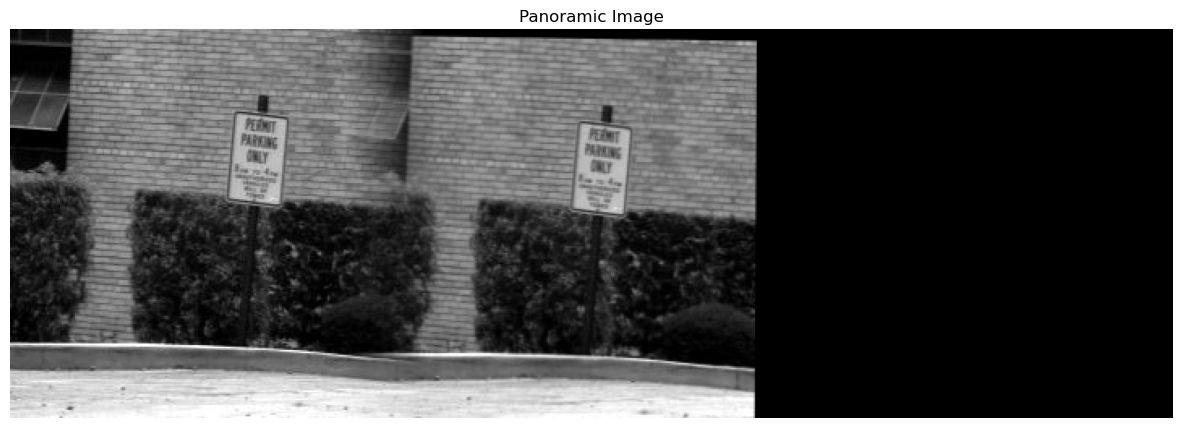

In [8]:
# Load and preprocess images
RGBimg1 = cv2.imread('images/shrub_L.jpg')  # Source image
RGBimg2 = cv2.imread('images/shrub_R.jpg')  # Destination image
img1 = img_as_float(color.rgb2gray(RGBimg1))
img2 = img_as_float(color.rgb2gray(RGBimg2))

# Detect keypoints and extract descriptors using ORB
detector = ORB(n_keypoints=500)

# Image 1
detector.detect_and_extract(img1)
keypoints1, descriptors1 = detector.keypoints, detector.descriptors

# Image 2
detector.detect_and_extract(img2)
keypoints2, descriptors2 = detector.keypoints, detector.descriptors

# Match descriptors using Euclidean distance
from scipy.spatial.distance import cdist
distances = cdist(descriptors1, descriptors2, metric='euclidean')
matches = []
for i, row in enumerate(distances):
    min_idx = np.argmin(row)
    if np.argmin(distances[:, min_idx]) == i:  # Mutual best match
        matches.append((keypoints1[i], keypoints2[min_idx]))

print(f"Number of matches: {len(matches)}")
if len(matches) < 4:
    print("Not enough matches to estimate a homography.")
else:
    model, inliers = compute_homography(matches, keypoints1, keypoints2)
    if model is not None:
        print(f"Number of inliers: {np.sum(inliers)}")

        # Warp the second image
        output_shape = (max(img1.shape[0], img2.shape[0]), img1.shape[1] + img2.shape[1])
        warped_img2 = warp_image(img2, model, output_shape=output_shape)

        # Blend the images
        panorama = blend_images(img1, warped_img2)

        # Visualize the result
        plt.figure(figsize=(15, 8))
        plt.imshow(panorama, cmap=cm.gist_gray)
        plt.title("Panoramic Image")
        plt.axis("off")
        plt.show()


In [ ]:
import cv2
import numpy as np

# 1. Read the images
# Replace 'image1.jpg' and 'image2.jpg' with your actual image paths
img1 = cv2.imread('images/shrub_L.jpg', cv2.IMREAD_COLOR)
img2 = cv2.imread('images/shrub_R.jpg', cv2.IMREAD_COLOR)

# Convert to grayscale for feature detection
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# 2. Detect keypoints and compute descriptors
# Here we use SIFT; if you prefer ORB, just replace with cv2.ORB_create()
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

# 3. Match descriptors using BFMatcher (with default params)
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)  # k=2 returns the two best matches per descriptor

# Lowe's ratio test to filter good matches
good_matches = []
ratio_thresh = 0.75
for m, n in matches:
    if m.distance < ratio_thresh * n.distance:
        good_matches.append(m)

print(f"Found {len(good_matches)} good matches.")

# 4. Estimate Homography if we have enough good matches
MIN_MATCH_COUNT = 10  # set a reasonable minimum
if len(good_matches) > MIN_MATCH_COUNT:
    # Extract location of good matches
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    # Calculate Homography using RANSAC
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    if H is not None:
        # 5. Warp image1 (img1) to align with image2 (img2)
        
        # First, get dimensions of the second image; we will warp img1 into this space.
        h2, w2 = img2.shape[:2]
        
        # Warp the first image
        warped_img1 = cv2.warpPerspective(img1, H, (w2, h2))
        
        # Show or save the result
        # Combine (for visualization) the warped first image and the original second image side by side
        combined = np.hstack((warped_img1, img2))
        cv2.imshow("Warped Image 1 (left) aligned with Image 2 (right)", combined)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
        
        # For a mosaic / panorama, you might need a bigger canvas
        # especially if image1 extends beyond image2 in some dimension.
        # E.g., get corners of image1, transform them, figure out new bounding box, etc.
    else:
        print("Homography could not be computed.")
else:
    print(f"Not enough matches are found - {len(good_matches)}/{MIN_MATCH_COUNT}")


Found 357 good matches.


In [ ]:
import cv2
import numpy as np

def create_panorama(img1, img2):
    """
    Creates a simple left-right panorama (mosaic) of img1 and img2
    by finding a homography that warps img2 into img1's coordinate system.
    """
    # 1. Convert to grayscale
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # 2. Detect keypoints and descriptors (SIFT or ORB)
    # Note: SIFT is in opencv-contrib-python; ORB is built into main OpenCV.
    sift = cv2.SIFT_create()  # or cv2.ORB_create()
    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    # 3. Match descriptors
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)

    # 4. Filter matches using Lowe's ratio test
    good = []
    ratio_thresh = 0.75
    for m, n in matches:
        if m.distance < ratio_thresh * n.distance:
            good.append(m)
    
    # Require a minimum number of good matches to proceed
    MIN_MATCH_COUNT = 8
    if len(good) < MIN_MATCH_COUNT:
        print(f"Not enough good matches: {len(good)}/{MIN_MATCH_COUNT}")
        return None

    # 5. Estimate Homography using the good matches
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)

    # Note: We want to warp img2 to img1, so we find H that maps img2->img1
    # So the arguments are (dst_pts -> src_pts)
    H, _ = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)

    # 6. Warp img2 into img1's coordinate space
    # First, figure out the size of the new panorama
    # We'll transform the corners of img2 to see how big it may extend.
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    # Corner points of img2
    corners_img2 = np.float32([[0,0], [w2,0], [w2,h2], [0,h2]]).reshape(-1,1,2)
    # Warp the corner points into img1 space
    warped_corners_img2 = cv2.perspectiveTransform(corners_img2, H)

    # Combine these corners with the corners of img1 to find overall bounding box
    corners_img1 = np.float32([[0,0], [w1,0], [w1,h1], [0,h1]]).reshape(-1,1,2)
    all_corners = np.concatenate((corners_img1, warped_corners_img2), axis=0)

    [xmin, ymin] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [xmax, ymax] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

    # Translate (shift) any negative coordinates so we can place them in a positive canvas
    t = [-xmin, -ymin]
    H_translate = np.array([[1, 0, t[0]],
                            [0, 1, t[1]],
                            [0, 0, 1]], dtype=np.float32)

    # 7. Warp img2 with the translation offset
    panorama_width = xmax - xmin
    panorama_height = ymax - ymin

    # Warp the second image to the new (big) panorama canvas
    warped_img2 = cv2.warpPerspective(
        img2, 
        H_translate @ H,  # apply both H and the translation
        (panorama_width, panorama_height)
    )

    # 8. Paste img1 into this panorama canvas as well
    panorama = np.zeros((panorama_height, panorama_width, 3), dtype=np.uint8)
    # place img1 at the translated origin
    panorama[t[1]:h1+t[1], t[0]:w1+t[0]] = img1

    # Then overlay the warped_img2
    # For areas where warped_img2 is non-zero, we'll just overwrite for simplicity.
    # More advanced methods do alpha blending or multi-band blending.

    mask = (warped_img2 > 0)
    panorama[mask] = warped_img2[mask]

    return panorama


if __name__ == "__main__":
    # Replace with your actual image paths or loaded images
    img1 = cv2.imread("images/tajm2.jpg")
    img2 = cv2.imread("images/tajm3.jpg")

    # Ensure both are valid
    if img1 is None or img2 is None:
        print("Error loading images. Check paths.")
        exit()

    # Create the panorama
    pano = create_panorama(img1, img2)
    if pano is not None:
        cv2.imshow("Panorama", pano)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
        # Optionally save the result
        cv2.imwrite("panorama_resultX.jpg", pano)


- Load your two images (e.g., left and right).
- Detect keypoints and compute descriptors (SIFT, ORB, etc.).
- Match the descriptors (e.g., BFMatcher).
- Use RANSAC to compute a homography that warps one image onto the other.
- Warp the second image into the first image’s coordinate system.
- Create an output “canvas” large enough to hold both images, and copy/blend them into that canvas to form the panorama.

In [ ]:
import cv2
import numpy as np

def create_panorama(left_img, right_img):
    """
    Warps 'left_img' onto 'right_img' (i.e., we treat right_img as the reference),
    then creates a panorama that can accommodate both images.
    """
    # 1. Convert to grayscale
    gray_left = cv2.cvtColor(left_img, cv2.COLOR_BGR2GRAY)
    gray_right = cv2.cvtColor(right_img, cv2.COLOR_BGR2GRAY)

    # 2. Detect keypoints & descriptors (SIFT or ORB)
    sift = cv2.SIFT_create()  # or cv2.ORB_create()
    kp_left, des_left = sift.detectAndCompute(gray_left, None)
    kp_right, des_right = sift.detectAndCompute(gray_right, None)

    # 3. Match descriptors (BFMatcher)
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des_left, des_right, k=2)

    # 4. Ratio test
    good = []
    ratio_thresh = 0.75
    for m, n in matches:
        if m.distance < ratio_thresh * n.distance:
            good.append(m)

    # Require a minimum number of good matches to proceed
    MIN_MATCH_COUNT = 8
    if len(good) < MIN_MATCH_COUNT:
        print(f"Not enough good matches: {len(good)}/{MIN_MATCH_COUNT}")
        return None

    # 5. Compute the homography that maps left_img --> right_img
    #    So we use (src_pts = left, dst_pts = right).
    src_pts = np.float32([kp_left[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    dst_pts = np.float32([kp_right[m.trainIdx].pt for m in good]).reshape(-1,1,2)
    
    H, _ = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    # 6. Warp the LEFT image into the RIGHT image's coordinate space
    h_left, w_left = left_img.shape[:2]
    h_right, w_right = right_img.shape[:2]

    # Corners of the left image
    corners_left = np.float32([
        [0,0], [w_left,0],
        [w_left,h_left], [0,h_left]
    ]).reshape(-1,1,2)
    # Warp them via H to find where they land in right_img space
    warped_left_corners = cv2.perspectiveTransform(corners_left, H)

    # Combine with corners of the *right* image (the reference)
    corners_right = np.float32([
        [0,0], [w_right,0],
        [w_right,h_right], [0,h_right]
    ]).reshape(-1,1,2)

    # All corners in "right" coordinate space
    all_corners = np.concatenate((warped_left_corners, corners_right), axis=0)

    # 7. Compute bounding box that fits both sets of corners
    [xmin, ymin] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [xmax, ymax] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

    # Ensure we shift things if xmin or ymin are negative
    t = [-xmin, -ymin]
    H_translate = np.array([
        [1, 0, t[0]],
        [0, 1, t[1]],
        [0, 0, 1]
    ], dtype=np.float32)

    # Panorama dimensions
    pano_w = xmax - xmin
    pano_h = ymax - ymin

    # 8. Warp the left image onto this big canvas
    warped_left = cv2.warpPerspective(
        left_img,
        H_translate @ H,  # apply both the homography & translation
        (pano_w, pano_h)
    )

    # 9. Place the right image on the same canvas
    panorama = np.zeros((pano_h, pano_w, 3), dtype=np.uint8)
    # Paste the warped left image
    panorama[:warped_left.shape[0], :warped_left.shape[1]] = warped_left

    # Now overlay the right image in the correct location
    # The top-left corner of the right image in the new canvas is simply t
    # because the right image is our reference.
    offset_x, offset_y = t
    panorama[offset_y:offset_y+h_right, offset_x:offset_x+w_right] = right_img

    return panorama

if __name__ == "__main__":
    left_img = cv2.imread("images/tajm2.jpg")
    right_img = cv2.imread("images/tajm3.jpg")

    if left_img is None or right_img is None:
        print("Could not load images. Check paths.")
        exit()

    pano = create_panorama(left_img, right_img)
    if pano is not None:
        cv2.imshow("Panorama", pano)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
        cv2.imwrite("pano_result.jpg", pano)


# Key Points
## Homography vs. Simple Translation

If your images are only translated (no tilt or rotation), you could estimate a simpler 2×3 affine transform with cv2.estimateAffine2D. However, findHomography + RANSAC is more robust if there is a slight rotation or perspective change.

## Blending

The code above naïvely overwrites overlapping pixels. In real panorama stitching, more advanced blending (e.g., feathering, multi-band blending) is used to avoid visible seams.

## OpenCV’s Built‐In Stitcher

OpenCV also has a high-level Stitcher class (cv2.Stitcher_create()), which can handle multiple images and implement internal blending. The manual approach above is more flexible if you want to fine-tune each step.

## Performance

For very large images or many images, you may want to resize them first or switch to an algorithm specialized for panoramic stitching.

In [ ]:
import cv2
import numpy as np

def create_panorama(img1, img2):
    """
    Creates a simple left-right panorama (mosaic) of img1 and img2
    by finding a homography that warps img2 into img1's coordinate system.
    """
    # 1. Convert to grayscale
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # 2. Detect keypoints and descriptors
    sift = cv2.SIFT_create()  # or cv2.ORB_create()
    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    # 3. Match descriptors
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)

    # 4. Filter matches
    good = []
    ratio_thresh = 0.75
    for m, n in matches:
        if m.distance < ratio_thresh * n.distance:
            good.append(m)

    MIN_MATCH_COUNT = 8
    if len(good) < MIN_MATCH_COUNT:
        print(f"Not enough good matches: {len(good)}/{MIN_MATCH_COUNT}")
        return None

    # 5. Estimate Homography
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1,1,2)
    H, _ = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)

    # 6. Warp img2 into img1's coordinate space
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    corners_img2 = np.float32([[0,0],[w2,0],[w2,h2],[0,h2]]).reshape(-1,1,2)
    warped_corners_img2 = cv2.perspectiveTransform(corners_img2, H)
    corners_img1 = np.float32([[0,0],[w1,0],[w1,h1],[0,h1]]).reshape(-1,1,2)
    all_corners = np.concatenate((corners_img1, warped_corners_img2), axis=0)

    [xmin, ymin] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [xmax, ymax] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

    t = [-xmin, -ymin]
    H_translate = np.array([[1,0,t[0]],[0,1,t[1]],[0,0,1]], dtype=np.float32)
    panorama_width = xmax - xmin
    panorama_height = ymax - ymin

    warped_img2 = cv2.warpPerspective(img2, H_translate @ H,
                                      (panorama_width, panorama_height))

    panorama = np.zeros((panorama_height, panorama_width, 3), dtype=np.uint8)
    panorama[t[1]:h1+t[1], t[0]:w1+t[0]] = img1

    mask = (warped_img2 > 0)
    panorama[mask] = warped_img2[mask]

    return panorama

if __name__ == "__main__":
    img1 = cv2.imread("images/tajm2.jpg")
    img2 = cv2.imread("images/tajm3.jpg")

    if img1 is None or img2 is None:
        print("Error loading images. Check paths.")
        exit()

    pano = create_panorama(img1, img2)
    if pano is not None:
        # 1) Save the image first
        cv2.imwrite("panorama_resultX.jpg", pano)
        print("Panorama saved as 'panorama_resultX.jpg'.")

        # 2) Then show it
        cv2.imshow("Panorama", pano)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
    else:
        print("Panorama creation failed.")
